In [1]:
# Upload do arquivo para o dataset a partir do computador

from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded))

with open(file_name, 'r') as file:
  content = file.read()
  print("arquivo lido com sucesso!")



Saving brasil_solos_5m_20201104.csv to brasil_solos_5m_20201104.csv
arquivo lido com sucesso!


In [2]:
import pandas as pd
import io

# visualização do topo da tabela:
df = pd.read_csv(io.StringIO(content), sep=',')
df.head()

,FID,ogc_fid,simbolos,comp1,comp2,comp3,leg_desc,area_km2,ordem1,subordem1,gdegrupo1,ordem2,subordem2,gdegrupo2,ordem3,subordem3,gdegrupo3,leg_sinot,classe_dom,geometry
0,brasil_solos_5m_20201104.1,1,AGUA,AGUA,NaN,NaN,AGUA,682.117090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGUA,AGUA,MULTIPOLYGON (((-52.56584167480469 -32.7660789...
1,brasil_solos_5m_20201104.2,2,AGUA,AGUA,NaN,NaN,AGUA,2397.827537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGUA,AGUA,MULTIPOLYGON (((-52.59645843505858 -32.5152130...
2,brasil_solos_5m_20201104.3,3,DN,Dunas,NaN,NaN,DN - Dunas,993.422475,DUNAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DN - Dunas,DN,MULTIPOLYGON (((-52.183261871337905 -32.149219...
3,brasil_solos_5m_20201104.4,4,DN,Dunas,NaN,NaN,DN - Dunas,37.619238,DUNAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DN - Dunas,DN,MULTIPOLYGON (((-52.1424980163574 -31.95138740...
4,brasil_solos_5m_20201104.5,5,SXe7,Planossolos Haplicos Eutroficos,Gleissolos Salicos Orticos,NaN,SXe7 - Planossolos Haplicos Eutroficos + Plano...,6121.567956,PLANOSSOLOS,HAPLICOS,Eutroficos,GLEISSOLOS,SALICOS,Orticos,NaN,NaN,NaN,SXe - Planossolos Haplicos Eutroficos,SXe,MULTIPOLYGON (((-52.230102539062514 -31.763816...


**SMOTE**


Distribuição real das classes no seu dataset:
ordem1
LATOSSOLOS                677
ARGISSOLOS                583
NEOSSOLOS                 463
GLEISSOLOS                325
PLINTOSSOLOS              178
CAMBISSOLOS               130
ESPODOSSOLOS               90
PLANOSSOLOS                66
LUVISSOLOS                 60
NITOSSOLOS                 48
CHERNOSSOLOS               20
AFLORAMENTOS DE ROCHAS     13
VERTISSOLOS                13
ORGANOSSOLOS                5
DUNAS                       4
Name: count, dtype: int64
--------------------------------------------------
Distribuição das ordens no treino APÓS o SMOTE:
ordem1
ARGISSOLOS                474
NEOSSOLOS                 474
LATOSSOLOS                474
GLEISSOLOS                474
PLINTOSSOLOS              474
CAMBISSOLOS               474
LUVISSOLOS                474
PLANOSSOLOS               474
NITOSSOLOS                474
ESPODOSSOLOS              474
CHERNOSSOLOS              474
VERTISSOLOS               474
AFLO

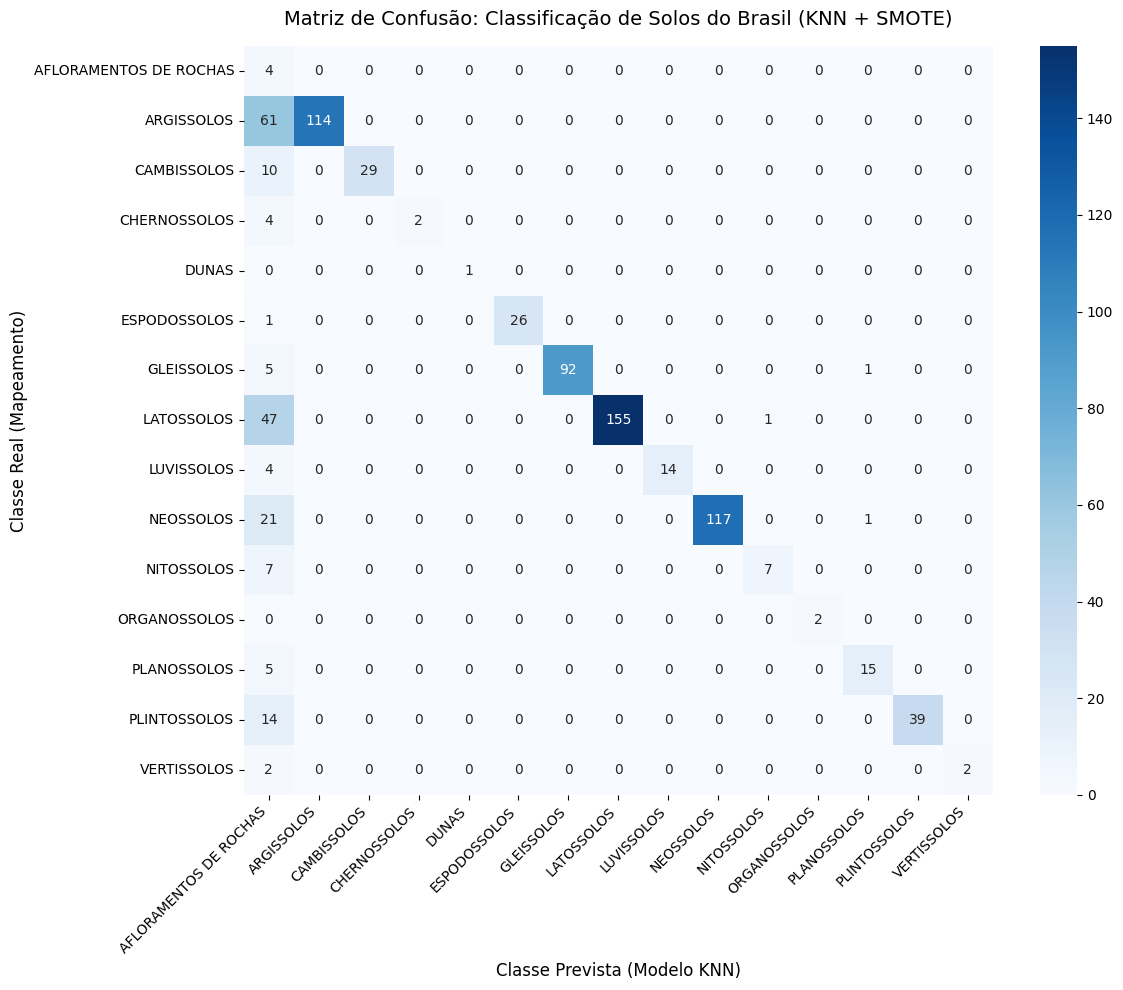

In [3]:
# Instalação e importações de bibliotecas


!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE



# Limpeza do dataset
df = df.dropna(subset=['ordem1'])
df = df[~df['ordem1'].isin(['AGUA', 'URBANA', 'CORREGO'])]

colunas_para_remover = ['FID', 'ogc_fid', 'leg_desc', 'leg_sinot', 'geometry', 'ordem1']
X_bruto = df.drop(columns=colunas_para_remover, errors='ignore')

y = df['ordem1'] # nitossolos


# Como colunas como 'comp1' e 'subordem1' são texto, transformamos em números (0 e 1)
# O KNN precisa de dados puramente numéricos para calcular distâncias
X = pd.get_dummies(X_bruto, drop_first=True)

print("\nDistribuição real das classes no seu dataset:")
print(y.value_counts())
print("-" * 50)


# Divisão do dataset em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# Aplicação do SMOTE no modelo de treinamento
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição das ordens no treino APÓS o SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("-" * 50)

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Treinamento e Predição
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_resampled)

y_pred_knn = knn.predict(X_test_scaled)


# Métricas e gráficos
print("Relatório de Classificação Final:")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusão
class_names = sorted(list(set(y_test)))
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar=True)

plt.title('Matriz de Confusão: Classificação de Solos do Brasil (KNN + SMOTE)', fontsize=14, pad=15)
plt.ylabel('Classe Real (Mapeamento)', fontsize=12)
plt.xlabel('Classe Prevista (Modelo KNN)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**ADASYN**

Distribuição real das classes no seu dataset:
ordem1
LATOSSOLOS                677
ARGISSOLOS                583
NEOSSOLOS                 463
GLEISSOLOS                325
PLINTOSSOLOS              178
CAMBISSOLOS               130
ESPODOSSOLOS               90
PLANOSSOLOS                66
LUVISSOLOS                 60
NITOSSOLOS                 48
CHERNOSSOLOS               20
AFLORAMENTOS DE ROCHAS     13
VERTISSOLOS                13
ORGANOSSOLOS                5
DUNAS                       4
Name: count, dtype: int64
--------------------------------------------------
Distribuição das ordens no treino APÓS o ADASYN:
ordem1
LATOSSOLOS                474
DUNAS                     474
ARGISSOLOS                408
NEOSSOLOS                 324
GLEISSOLOS                227
PLINTOSSOLOS              125
CAMBISSOLOS                91
ESPODOSSOLOS               63
PLANOSSOLOS                46
LUVISSOLOS                 42
NITOSSOLOS                 34
CHERNOSSOLOS               14
VERT

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


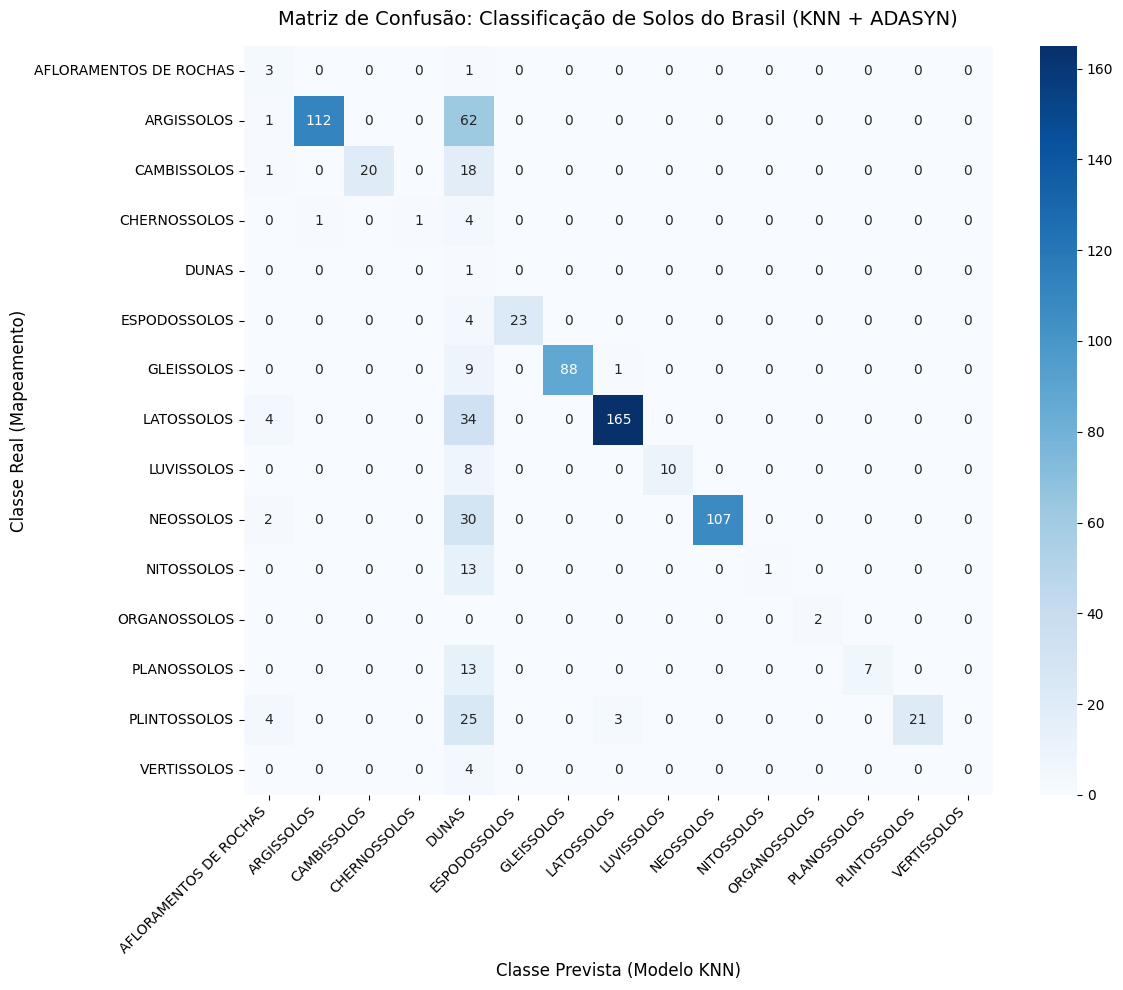

In [4]:
# Instalação e importação de bibliotecas


!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import ADASYN


# Limpeza dos alvos não mapeáveis
df = df.dropna(subset=['ordem1'])
df = df[~df['ordem1'].isin(['AGUA', 'URBANA', 'CORREGO'])]


y = df['ordem1'] # nitossolos

colunas_para_remover = ['FID', 'ogc_fid', 'leg_desc', 'leg_sinot', 'geometry', 'ordem1']
X_bruto = df.drop(columns=colunas_para_remover, errors='ignore')

# Transformando variáveis categóricas em numéricas para o KNN
X = pd.get_dummies(X_bruto, drop_first=True)

print("Distribuição real das classes no seu dataset:")
print(y.value_counts())
print("-" * 50)


# Treinamento e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicação do Adasyn apenas no modelo de treinamento
# E utilização do  'minority' como estratégia de amostragem para permitir que o ADASYN decida as quantidades
adasyn = ADASYN(random_state=42, n_neighbors=1, sampling_strategy='minority')
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

print("Distribuição das ordens no treino APÓS o ADASYN:")
print(pd.Series(y_train_resampled).value_counts())
print("-" * 50)

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


# Treinamento e predição
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_resampled)

y_pred_knn = knn.predict(X_test_scaled)

# Métricas e gráficos
print("Relatório de Classificação Final (KNN + ADASYN):")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusão
class_names = sorted(list(set(y_test)))
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar=True)

plt.title('Matriz de Confusão: Classificação de Solos do Brasil (KNN + ADASYN)', fontsize=14, pad=15)
plt.ylabel('Classe Real (Mapeamento)', fontsize=12)
plt.xlabel('Classe Prevista (Modelo KNN)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Distribuição real das classes no seu dataset:
ordem1
LATOSSOLOS                677
ARGISSOLOS                583
NEOSSOLOS                 463
GLEISSOLOS                325
PLINTOSSOLOS              178
CAMBISSOLOS               130
ESPODOSSOLOS               90
PLANOSSOLOS                66
LUVISSOLOS                 60
NITOSSOLOS                 48
CHERNOSSOLOS               20
AFLORAMENTOS DE ROCHAS     13
VERTISSOLOS                13
ORGANOSSOLOS                5
DUNAS                       4
Name: count, dtype: int64
--------------------------------------------------
Distribuição das ordens no treino APÓS o SMOTE:
ordem1
ARGISSOLOS                474
NEOSSOLOS                 474
LATOSSOLOS                474
GLEISSOLOS                474
PLINTOSSOLOS              474
CAMBISSOLOS               474
LUVISSOLOS                474
PLANOSSOLOS               474
NITOSSOLOS                474
ESPODOSSOLOS              474
CHERNOSSOLOS              474
VERTISSOLOS               474
AFLO

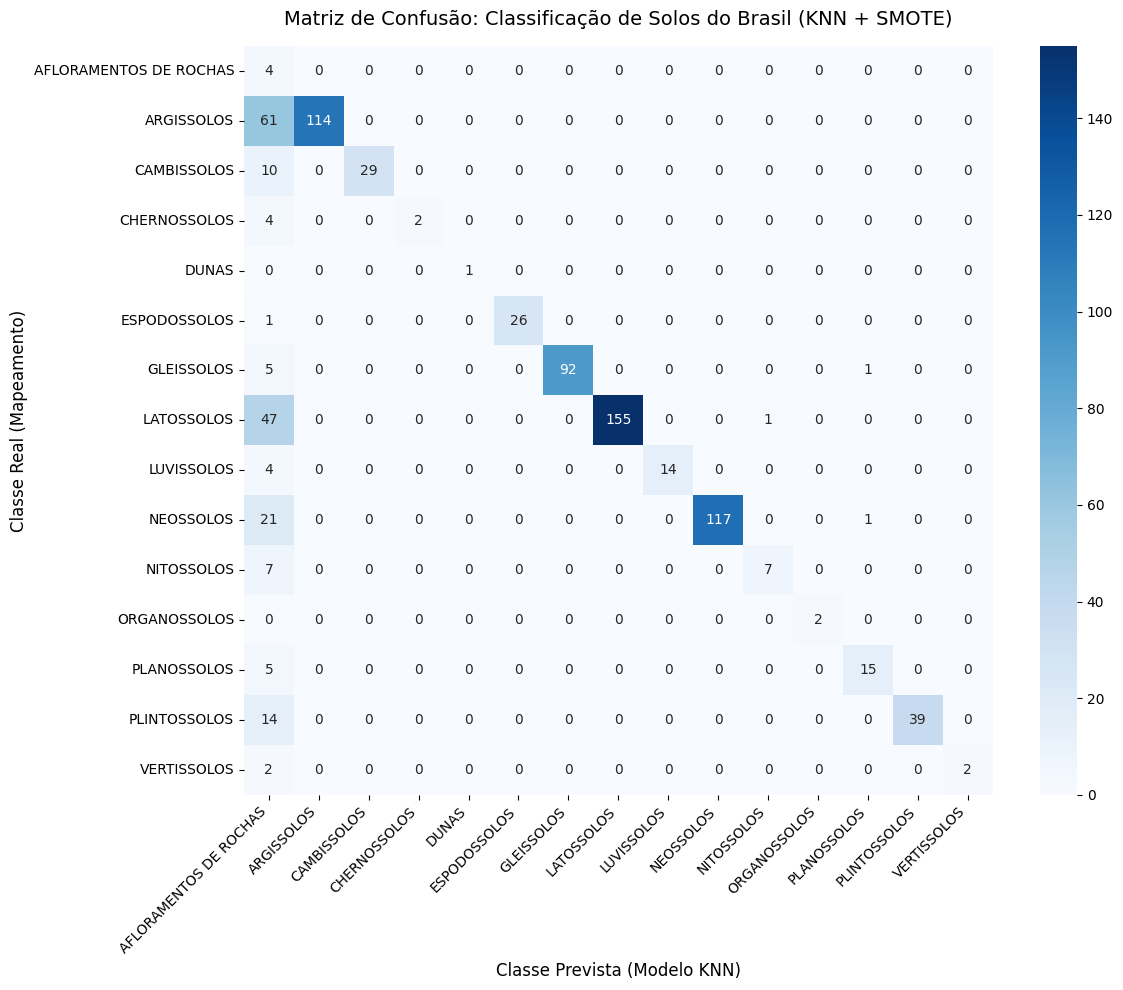

In [ ]:
# Instalação e importações de bibliotecas

!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE


# Limpeza do dataset
df = df.dropna(subset=['ordem1'])
df = df[~df['ordem1'].isin(['AGUA', 'URBANA', 'CORREGO'])]

colunas_para_remover = ['FID', 'ogc_fid', 'leg_desc', 'leg_sinot', 'geometry', 'ordem1']
X_bruto = df.drop(columns=colunas_para_remover, errors='ignore')

y = df['ordem1'] # nitossolos


# Como colunas como 'comp1' e 'subordem1' são texto, transformamos em números (0 e 1)
# O KNN precisa de dados puramente numéricos para calcular distâncias
X = pd.get_dummies(X_bruto, drop_first=True)

print("\nDistribuição real das classes no seu dataset:")
print(y.value_counts())
print("-" * 50)


# Divisão do dataset em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# Aplicação do SMOTE no modelo de treinamento
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição das ordens no treino APÓS o SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("-" * 50)

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Treinamento e Predição
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_resampled)

y_pred_knn = knn.predict(X_test_scaled)


# Métricas e gráficos
print("Relatório de Classificação Final:")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusão
class_names = sorted(list(set(y_test)))
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar=True)

plt.title('Matriz de Confusão: Classificação de Solos do Brasil (KNN + SMOTE)', fontsize=14, pad=15)
plt.ylabel('Classe Real (Mapeamento)', fontsize=12)
plt.xlabel('Classe Prevista (Modelo KNN)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Otimizando o KNN com GridSearchCV

Usando o `GridSearchCV` para encontrar o melhor número de vizinhos (`n_neighbors`) para o `KNeighborsClassifier`. Isso pode ajudará o modelo a melhorar o reconhecimento das classes minoritárias.

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Melhores hiperparâmetros: {'n_neighbors': 1}
Melhor F1-score macro: 0.7900

Relatório de Classificação Final (KNN Otimizado com ADASYN):
                        precision    recall  f1-score   support

AFLORAMENTOS DE ROCHAS       0.67      1.00      0.80         4
            ARGISSOLOS       0.99      0.85      0.91       175
           CAMBISSOLOS       1.00      0.74      0.85        39
          CHERNOSSOLOS       1.00      0.33      0.50         6
                 DUNAS       0.01      1.00      0.02         1
          ESPODOSSOLOS       1.00      0.93      0.96        27
            GLEISSOLOS       1.00      0.95      0.97        98
            LATOSSOLOS       0.98      0.93      0.96       203
            LUVISSOLOS       1.00      0.78      0.88        18
             NEOSSOLOS       1.00      0.93      0.96       139
            NITOSSOLOS       1.00      0.50      0.67        14
          ORGANOSSOLOS       1.00      1.00      1.00         2
           PLANOSSOLOS       1

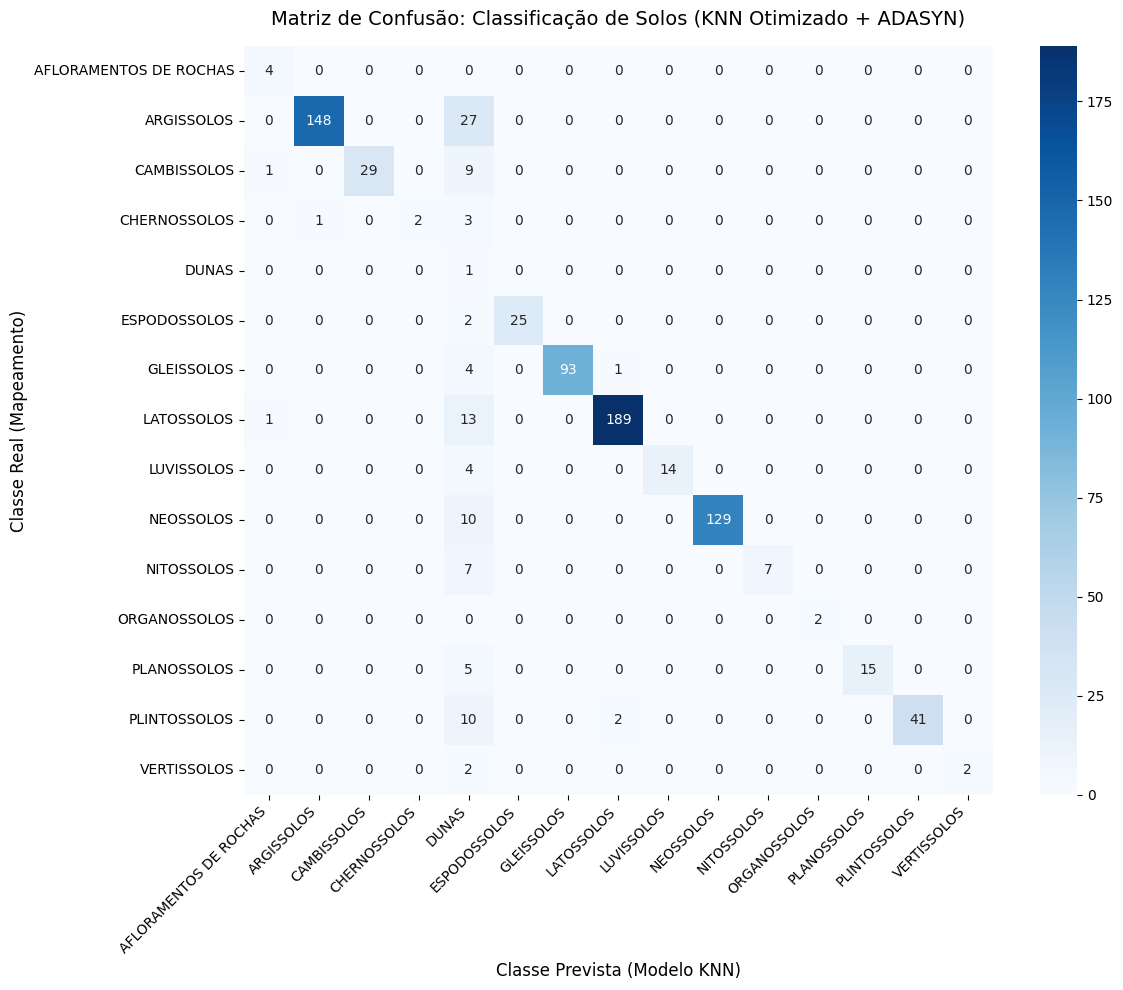

In [5]:
from sklearn.model_selection import GridSearchCV

# Definir os parâmetros a serem testados
param_grid = {'n_neighbors': range(1, 21)} # Testar de 1 a 20 vizinhos

# Criar o objeto GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1_macro', n_jobs=-1) # cv=5 para validação cruzada, scoring='f1_macro' para lidar com desbalanceamento

# Ajustar o GridSearchCV aos dados de treino reamostrados e padronizados
grid_search.fit(X_train_scaled, y_train_resampled)

print(f"Melhores hiperparâmetros: {grid_search.best_params_}")
print(f"Melhor F1-score macro: {grid_search.best_score_:.4f}")

# Obter o melhor modelo
best_knn = grid_search.best_estimator_

# Fazer previsões com o melhor modelo
y_pred_best_knn = best_knn.predict(X_test_scaled)

# Avaliar o melhor modelo
print("\nRelatório de Classificação Final (KNN Otimizado com ADASYN):")
print(classification_report(y_test, y_pred_best_knn))

# Gerar a Matriz de Confusão para o melhor modelo
cm_best = confusion_matrix(y_test, y_pred_best_knn)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar=True)

plt.title('Matriz de Confusão: Classificação de Solos (KNN Otimizado + ADASYN)', fontsize=14, pad=15)
plt.ylabel('Classe Real (Mapeamento)', fontsize=12)
plt.xlabel('Classe Prevista (Modelo KNN)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()